# Upscale — static methods

The upscalers that need no model at all: resampling filters, the ones already sitting in
every image library, browser and GPU driver. They are the dummy baseline in both senses
that matter — the quality a learned model has to beat, and the runtime it has to beat it
*within*.

The second half is what usually decides this. A static filter costs a fraction of a
millisecond and runs anywhere, so a network is not competitive at 1 dB better and 40 ms;
it is competitive at 1 dB better and inside the frame budget. Measuring the cheap option
properly is what makes that comparison real.

Runs on the patches `data_preprocess.ipynb` wrote. The learned attempt is in
`upscale_nn.ipynb`.

In [1]:
"""Configuration."""

from pathlib import Path

DATA_DIR = Path("data/processed")
RAW_DIR = Path("data/raw")

# Batch of one, at the output resolutions a client would actually ask for.
BENCH_RESOLUTIONS = [(480, 270), (640, 360), (960, 540), (1280, 720)]
BENCH_LR_SIZE = (320, 180)                  # input for the batch sweep, kept small
BENCH_BATCHES = [1, 2, 4, 8, 16]
SEED = 0

In [2]:
"""Imports, and the validation split every quality number below is measured on."""

import json
import time

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

if not (DATA_DIR / "manifest.json").exists():
    raise RuntimeError(f"no dataset in {DATA_DIR} — run data_preprocess.ipynb first")

manifest = json.loads((DATA_DIR / "manifest.json").read_text(encoding="utf-8"))
SCALE = manifest["scale"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

val = manifest["splits"]["val"]
lr_patches = np.load(DATA_DIR / val["lr"])
hr_patches = np.load(DATA_DIR / val["hr"])

print("scale ", SCALE)
print("device", DEVICE.type, f"{torch.get_num_threads()} threads" if DEVICE.type == "cpu"
      else torch.cuda.get_device_name(0))
print("val   ", lr_patches.shape, "->", hr_patches.shape)

scale  2
device cpu 12 threads
val    (76, 64, 64, 3) -> (76, 128, 128, 3)


## The methods

Six resampling filters, ordered by how much of the neighbourhood they look at. **Nearest**
copies a pixel and is the only one that invents nothing, which on text is either exactly
right or blocky. **Box** and **bilinear** average a small neighbourhood. **Hamming**,
**bicubic** and **Lanczos** use a windowed kernel over a wider one — sharper, at the cost
of ringing on hard edges, which a desktop frame is made of.

**Box scores identically to nearest**, and that is correct rather than a bug: box
averaging over an integer upscale has exactly one source pixel per output pixel, so it
*is* replication. It stays in the table because that equality is worth seeing.

Then one that is not a filter: **bicubic + unsharp**, a bicubic upscale with an unsharp
mask over it. It is still static, still cheap, and it is the honest strong baseline,
because sharpening after upscaling is what a video player would already be doing. Here it
wins outright, on PSNR as well as on appearance — expect that to be flattered by this
dataset: the degradation is a clean bicubic blur with nothing else in it, and sharpening
partly inverts exactly that. On real captures the same filter also sharpens the codec
artifacts, and the ranking is not safe to carry over untested.

In [3]:
"""The static upscalers, and PSNR over uint8 arrays."""

FILTERS = {
    "nearest": Image.NEAREST,
    "box": Image.BOX,
    "bilinear": Image.BILINEAR,
    "hamming": Image.HAMMING,
    "bicubic": Image.BICUBIC,
    "lanczos": Image.LANCZOS,
}

UNSHARP = ImageFilter.UnsharpMask(radius=1.0, percent=80, threshold=0)


def upscale(image, scale, method):
    """One PIL image up by `scale`. `method` is a filter name, or bicubic + unsharp."""
    size = (image.width * scale, image.height * scale)
    if method == "bicubic + unsharp":
        return image.resize(size, Image.BICUBIC).filter(UNSHARP)
    return image.resize(size, FILTERS[method])


METHODS = list(FILTERS) + ["bicubic + unsharp"]


def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return 10.0 * np.log10(255.0 ** 2 / max(mse, 1e-12))


print(len(METHODS), "methods:", ", ".join(METHODS))

7 methods: nearest, box, bilinear, hamming, bicubic, lanczos, bicubic + unsharp


In [4]:
"""Quality: every method over every validation patch."""

quality = {}
for method in METHODS:
    scores = [psnr(np.asarray(upscale(Image.fromarray(lr), SCALE, method)), hr)
              for lr, hr in zip(lr_patches, hr_patches)]
    quality[method] = {"mean": float(np.mean(scores)), "std": float(np.std(scores))}

best = max(quality, key=lambda m: quality[m]["mean"])

print(f"{len(lr_patches)} validation patches, "
      f"{lr_patches.shape[1]}px -> {hr_patches.shape[1]}px\n")
print(f"{'method':>18}  {'PSNR':>7}  {'std':>5}  {'vs nearest':>10}")
for method, score in sorted(quality.items(), key=lambda item: -item[1]["mean"]):
    print(f"{method:>18}  {score['mean']:7.2f}  {score['std']:5.2f}  "
          f"{score['mean'] - quality['nearest']['mean']:+9.2f} dB"
          f"{'   <- best' if method == best else ''}")

76 validation patches, 64px -> 128px

            method     PSNR    std  vs nearest
 bicubic + unsharp    23.62   5.75      +1.35 dB   <- best
           lanczos    23.41   5.76      +1.14 dB
           bicubic    23.33   5.73      +1.06 dB
          bilinear    22.74   5.65      +0.47 dB
           hamming    22.66   5.78      +0.39 dB
           nearest    22.27   5.98      +0.00 dB
               box    22.27   5.98      +0.00 dB


In [5]:
"""The same on a whole frame, where a filter has more than 64 pixels to work with."""

source = sorted(RAW_DIR.glob("*.png"))[0]
truth = Image.open(source).convert("RGB")
truth = truth.crop((0, 0, truth.width - truth.width % SCALE, truth.height - truth.height % SCALE))
small = truth.resize((truth.width // SCALE, truth.height // SCALE), Image.BICUBIC)
truth_array = np.asarray(truth)

frame_quality = {m: psnr(np.asarray(upscale(small, SCALE, m)), truth_array) for m in METHODS}

print(f"{source.name}  {small.size} -> {truth.size}\n")
for method, score in sorted(frame_quality.items(), key=lambda item: -item[1]):
    print(f"{method:>18}  {score:7.2f} dB")

synthetic_0000.png  (480, 300) -> (960, 600)

 bicubic + unsharp    24.13 dB
           lanczos    23.95 dB
           bicubic    23.88 dB
           hamming    23.58 dB
          bilinear    23.51 dB
           nearest    23.39 dB
               box    23.39 dB


## What they look like

The numbers rank the filters; this says what the ranking is made of. Look at the text rows
and the window edges — nearest goes blocky, and the wide kernels ring around the hard
edges a desktop frame is full of, which is the cost their extra dB is paid with.

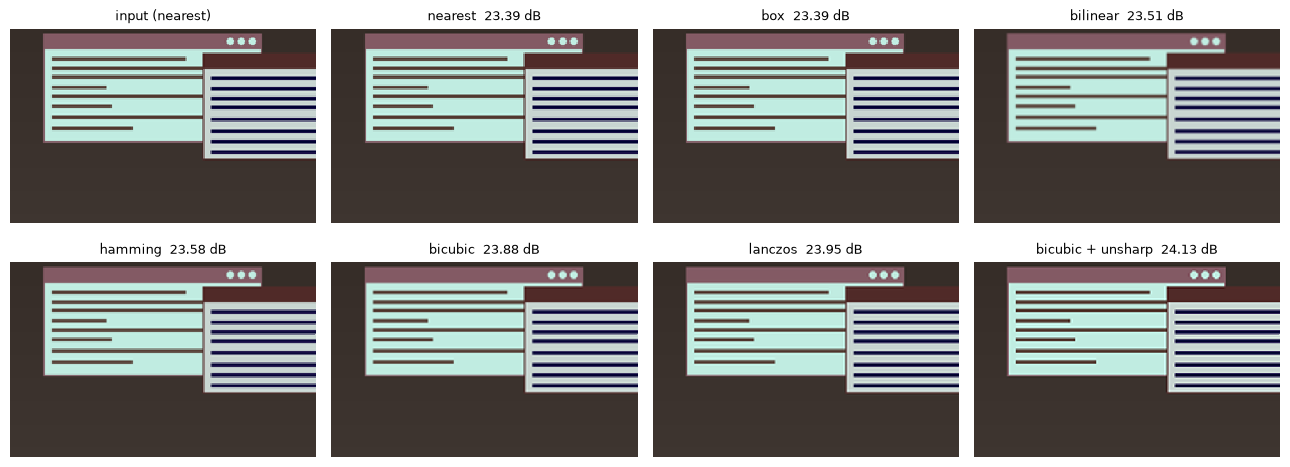

In [6]:
"""One crop through every method, at 1:1 pixels."""

crop = (0, 0, min(220, small.width), min(140, small.height))
detail = small.crop(crop)

fig, axes = plt.subplots(2, 4, figsize=(13, 5))
panels = [("input (nearest)", detail.resize((detail.width * SCALE, detail.height * SCALE),
                                            Image.NEAREST))]
panels += [(f"{m}  {frame_quality[m]:.2f} dB", upscale(detail, SCALE, m)) for m in METHODS]

for ax, (name, image) in zip(axes.ravel(), panels):
    ax.imshow(image, interpolation="nearest")
    ax.set_title(name, fontsize=9)
    ax.axis("off")
fig.tight_layout()
plt.show()

## Runtime

Two backends, because they are two different answers to the same question. **PIL** is one
image at a time on the CPU, which is what a client doing this outside a tensor pipeline
would use, and the only one of the two that offers Lanczos at all. **torch** is
`F.interpolate`, batched, and the same call a network would make internally — so it is the
number to hold the learned model against.

Batch of one is the honest figure for a live stream: frames arrive one at a time and each
is wanted now, so the per-frame cost has to fit the frame interval (16.7 ms at 60 fps,
33.3 ms at 30 fps) with decode, draw and everything else already in it.

In [7]:
"""Time a callable, adapting the repeat count to how slow one pass turns out to be."""

def measure(run, seconds=0.5, warmup=2):
    for _ in range(warmup):
        run()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    started = time.perf_counter()
    run()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    once = time.perf_counter() - started

    reps = max(3, min(200, int(seconds / max(once, 1e-9))))
    started = time.perf_counter()
    for _ in range(reps):
        run()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - started) / reps * 1000.0


rng = np.random.default_rng(SEED)


def noise_image(size):
    return Image.fromarray(rng.integers(0, 255, (size[1], size[0], 3), dtype=np.uint8))


print("timing harness ready")

timing harness ready


In [8]:
"""PIL, one frame at a time, at the resolutions a client would ask for."""

pil_runtime = {}
for size in BENCH_RESOLUTIONS:
    image = noise_image(size)
    pil_runtime[size] = {m: measure(lambda m=m: upscale(image, SCALE, m)) for m in METHODS}

header = "".join(f"{m.replace('bicubic + unsharp', 'unsharp'):>10}" for m in METHODS)
print(f"{'output':>12}{header}")
for size, row in pil_runtime.items():
    out = f"{size[0] * SCALE}x{size[1] * SCALE}"
    print(f"{out:>12}" + "".join(f"{row[m]:10.2f}" for m in METHODS))
print("\nms per frame, batch of one")

      output   nearest       box  bilinear   hamming   bicubic   lanczos   unsharp
     960x540      0.63      1.89      2.44      2.50      3.58      4.81     16.59
    1280x720      1.10      3.78      4.61      4.78      6.71      9.01     30.09
   1920x1080      2.31      8.06     10.22     10.35     14.77     19.95     66.96
   2560x1440      4.11     14.16     18.28     18.29     26.63     35.49    119.63

ms per frame, batch of one


In [9]:
"""torch F.interpolate, batch of one, at the same resolutions."""

TORCH_MODES = ["nearest", "bilinear", "bicubic"]


def torch_upscale(x, mode):
    if mode == "nearest":
        return F.interpolate(x, scale_factor=SCALE, mode="nearest")
    return F.interpolate(x, scale_factor=SCALE, mode=mode, align_corners=False)


torch_runtime = {}
for size in BENCH_RESOLUTIONS:
    x = torch.rand(1, 3, size[1], size[0], device=DEVICE)
    torch_runtime[size] = {mode: measure(lambda mode=mode: torch_upscale(x, mode))
                           for mode in TORCH_MODES}

print(f"{'output':>12}" + "".join(f"{mode:>10}" for mode in TORCH_MODES) + "   frame budget")
for size, row in torch_runtime.items():
    out = f"{size[0] * SCALE}x{size[1] * SCALE}"
    slowest = max(row.values())
    budget = "60 fps" if slowest <= 16.7 else "30 fps" if slowest <= 33.3 else "under 30 fps"
    print(f"{out:>12}" + "".join(f"{row[mode]:10.2f}" for mode in TORCH_MODES) + f"   {budget}")
print("\nms per frame, batch of one")

      output   nearest  bilinear   bicubic   frame budget
     960x540      0.25      0.96      3.44   60 fps
    1280x720      0.42      1.67      5.89   60 fps
   1920x1080      1.00      3.80     13.29   60 fps
   2560x1440      1.99      6.71     22.41   30 fps

ms per frame, batch of one


In [10]:
"""What a batch buys, at 320x180 -> 640x360."""

sweep = {}
for mode in TORCH_MODES:
    sweep[mode] = {}
    for batch in BENCH_BATCHES:
        x = torch.rand(batch, 3, BENCH_LR_SIZE[1], BENCH_LR_SIZE[0], device=DEVICE)
        per_batch = measure(lambda x=x, mode=mode: torch_upscale(x, mode))
        sweep[mode][batch] = {"ms_batch": per_batch, "ms_frame": per_batch / batch}

print(f"{'batch':>5}" + "".join(f"{mode:>22}" for mode in TORCH_MODES))
print(f"{'':>5}" + "".join(f"{'ms/batch':>11}{'ms/frame':>11}" for _ in TORCH_MODES))
for batch in BENCH_BATCHES:
    print(f"{batch:5}" + "".join(f"{sweep[m][batch]['ms_batch']:11.2f}"
                                 f"{sweep[m][batch]['ms_frame']:11.2f}" for m in TORCH_MODES))

print("\nper-frame change from batch 1 to batch "
      f"{BENCH_BATCHES[-1]}: " + ", ".join(
          f"{m} {sweep[m][BENCH_BATCHES[0]]['ms_frame'] / sweep[m][BENCH_BATCHES[-1]]['ms_frame']:.2f}x"
          for m in TORCH_MODES))

batch               nearest              bilinear               bicubic
        ms/batch   ms/frame   ms/batch   ms/frame   ms/batch   ms/frame
    1       0.12       0.12       0.44       0.44       1.62       1.62
    2       0.22       0.11       0.86       0.43       3.05       1.53
    4       0.43       0.11       1.67       0.42       5.91       1.48
    8       0.85       0.11       3.44       0.43      11.78       1.47
   16       2.00       0.13       6.72       0.42      23.03       1.44

per-frame change from batch 1 to batch 16: nearest 0.94x, bilinear 1.05x, bicubic 1.12x


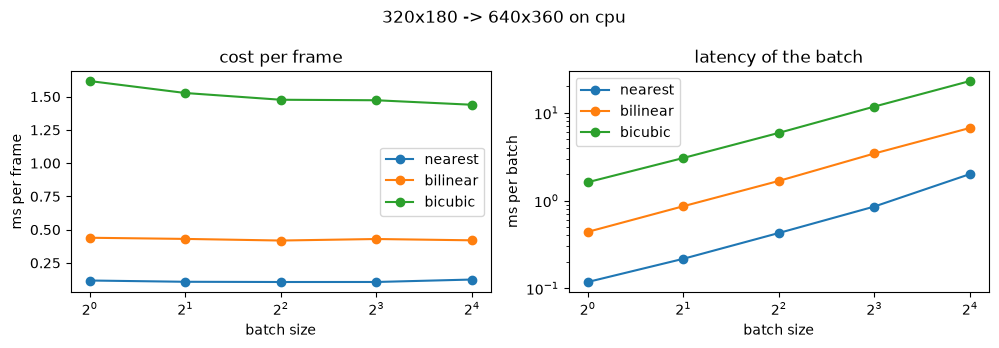

In [11]:
"""The sweep as a picture."""

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.5))
for mode in TORCH_MODES:
    left.plot(BENCH_BATCHES, [sweep[mode][b]["ms_frame"] for b in BENCH_BATCHES], "o-", label=mode)
    right.plot(BENCH_BATCHES, [sweep[mode][b]["ms_batch"] for b in BENCH_BATCHES], "o-", label=mode)

left.set_xscale("log", base=2)
left.set_xlabel("batch size")
left.set_ylabel("ms per frame")
left.set_title("cost per frame")
left.legend()

right.set_xscale("log", base=2)
right.set_yscale("log")
right.set_xlabel("batch size")
right.set_ylabel("ms per batch")
right.set_title("latency of the batch")
right.legend()

fig.suptitle(f"{BENCH_LR_SIZE[0]}x{BENCH_LR_SIZE[1]} -> "
             f"{BENCH_LR_SIZE[0] * SCALE}x{BENCH_LR_SIZE[1] * SCALE} on {DEVICE.type}")
fig.tight_layout()
plt.show()

## The bar

What comes out of this notebook is one line for `upscale_nn.ipynb` to be measured against:
the best static PSNR, and the runtime it was free at.

In [12]:
"""The baseline a learned model has to beat, on both axes at once."""

reference = BENCH_RESOLUTIONS[1]
print(f"quality   {best} at {quality[best]['mean']:.2f} dB on validation patches")
print(f"          (bicubic {quality['bicubic']['mean']:.2f} dB, "
      f"nearest {quality['nearest']['mean']:.2f} dB)")
print(f"runtime   bicubic at {reference[0] * SCALE}x{reference[1] * SCALE}: "
      f"{torch_runtime[reference]['bicubic']:.2f} ms/frame (torch), "
      f"{pil_runtime[reference]['bicubic']:.2f} ms/frame (PIL)")
print(f"\na learned model earns its place by beating {quality[best]['mean']:.2f} dB "
      f"inside a frame budget this leaves almost entirely unspent")

quality   bicubic + unsharp at 23.62 dB on validation patches
          (bicubic 23.33 dB, nearest 22.27 dB)
runtime   bicubic at 1280x720: 5.89 ms/frame (torch), 6.71 ms/frame (PIL)

a learned model earns its place by beating 23.62 dB inside a frame budget this leaves almost entirely unspent


## Export to ONNX for the browser

The static filters are the bar, so they have to be measurable *where the models are* —
in the browser, through the same runtime, on the same tile. A desktop-CPU millisecond
from earlier in this notebook cannot be compared against a WebGPU millisecond from the
benchmark page, and comparing them anyway is how a model gets adopted on a number that
was never real.

A resampling filter has no weights, so what is exported is a graph of one node: `Resize`.
Three of the seven survive the trip — ONNX `Resize` offers **nearest**, **linear** and
**cubic**, and there is no box, hamming, Lanczos or unsharp to export. Those stay
notebook-only measurements.

`Resize` is also the operator a WebGPU provider is least likely to run natively, and a
fallback copies the tensor out to the CPU and back, once per frame. That is not a reason
to leave the baseline off the page — it is the reason to put it on. What the free option costs in a browser *includes* whether the
browser can run it, and the benchmark page is where that stops being a guess.

The halo is the filter's own support: nearest reads one pixel and needs none, bilinear
reaches one, bicubic two. Far smaller than a network's, which is part of why they are
cheap.

In [13]:
"""Export the resampling filters ONNX can express, and publish them to the benchmark page."""

import onnxruntime as ort
import torch
import torch.nn as nn

import webexport

SCALE = manifest["scale"]

# ONNX Resize mode, and the halo each filter's support needs, in LR pixels.
EXPORTABLE = {
    "nearest": {"mode": "nearest", "halo": 0},
    "bilinear": {"mode": "bilinear", "halo": 1},
    "bicubic": {"mode": "bicubic", "halo": 2},
}

# A 1920x1080 output is covered by this many 128-step tiles, which is how a per-tile
# millisecond becomes a per-frame one.
TILES_PER_1080P = (1920 // (webexport.TILE_STEP * SCALE) + 1) * (
    1080 // (webexport.TILE_STEP * SCALE) + 1)


class StaticUpscaler(nn.Module):
    """One resampling filter as a module, so torch.onnx.export can emit it as Resize."""

    def __init__(self, scale, mode):
        super().__init__()
        self.scale = scale
        self.mode = mode

    def forward(self, x):
        if self.mode == "nearest":
            return torch.nn.functional.interpolate(x, scale_factor=self.scale, mode="nearest")
        return torch.nn.functional.interpolate(x, scale_factor=self.scale, mode=self.mode,
                                               align_corners=False)


options = ort.SessionOptions()
options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

entries = []
for name, spec in EXPORTABLE.items():
    size = webexport.TILE_STEP + 2 * spec["halo"]
    module = StaticUpscaler(SCALE, spec["mode"])

    info = webexport.export(
        module, f"upscale_static_{name}_tile{webexport.TILE_STEP}.onnx", size,
        label=f"static {name} (Resize)", halo=spec["halo"])

    # The export has to agree with the PIL result the quality table above was measured
    # with, or the page would be benchmarking a different filter than this notebook scored.
    probe = torch.rand(1, 3, 32, 32)
    reference = torch.nn.functional.interpolate(
        probe, scale_factor=SCALE, mode=spec["mode"],
        **({} if spec["mode"] == "nearest" else {"align_corners": False}))
    assert torch.allclose(module(probe), reference), name

    # Time the exported graph, not the torch call. The page runs the graph through ONNX
    # Runtime and the two are not the same kernel - see below, where they disagree by 65x.
    # The input is allocated once and reused, because a torch.rand() inside the timed
    # region is more than half the cost of a nearest tile and none of it is the filter.
    tile = torch.rand(1, 3, size, size)
    sample = tile.numpy()
    session = ort.InferenceSession(str(info["path"]), options,
                                   providers=["CPUExecutionProvider"])
    torch_ms = measure(lambda m=module, t=tile: m(t))
    onnx_ms = measure(lambda s=session, x=sample: s.run(None, {"input": x}))

    # The page reads this back out of the file: there is no manifest to write it to.
    webexport.annotate(info, cpu_ms=round(onnx_ms, 2))

    entries.append(info)
    print(f"{name:>9}  {info['kb']:5.1f} KB  {size}x{size} -> {size * SCALE}x{size * SCALE}"
          f"   torch {torch_ms:7.3f} ms   onnxruntime {onnx_ms:8.3f} ms"
          f"   ({onnx_ms * TILES_PER_1080P:7.1f} ms per 1080p frame)")

print(f"\n{len(entries)} model(s) written to {webexport.MODELS_DIR.resolve()}")
for info in entries:
    warn = (f"   outside the op budget: {', '.join(info['outside_budget'])}"
            if info["outside_budget"] else "")
    print(f"  {info['path'].name}{warn}")

  nearest    0.4 KB  128x128 -> 256x256   torch   0.098 ms   onnxruntime    0.038 ms   (    1.5 ms per 1080p frame)
 bilinear    0.4 KB  130x130 -> 260x260   torch   0.352 ms   onnxruntime    0.290 ms   (   11.6 ms per 1080p frame)
  bicubic    0.4 KB  132x132 -> 264x264   torch   1.273 ms   onnxruntime   47.955 ms   ( 1918.2 ms per 1080p frame)

3 model(s) written to C:\Users\henrik\Downloads\desktop-streamer\model\upscale\benchmark\www\models
  upscale_static_nearest_tile128.onnx   outside the op budget: Resize
  upscale_static_bilinear_tile128.onnx   outside the op budget: Resize
  upscale_static_bicubic_tile128.onnx   outside the op budget: Resize


**Read the two runtime columns above rather than just the ONNX one.** They are the same
filter, in the same process, on the same tile, and for bicubic they disagree by about 65x:
`torch.nn.functional.interpolate` does the tile in well under a millisecond, and ONNX
Runtime's CPU `Resize` kernel takes tens. It is a flat ~230 ns per *output pixel*, it
scales linearly with the tile, it stays on one thread whatever `intra_op_num_threads`
says, and no attribute moves it - `coordinate_transformation_mode`, `exclude_outside` and
a dynamic input shape all measure the same. The same runtime's `linear` mode costs about
1 ns per output pixel, so this is not the price of the four extra taps: it is one
unoptimised kernel, and it is the one this baseline lands on.

That is worth knowing before reading a browser number for `static bicubic`, and it is an
argument about the harness rather than about bicubic. A browser upscaling a frame with a
static filter would never build an ONNX graph to do it - `drawImage` on a canvas, or a
texture sampler, does bilinear and bicubic in the fixed-function path for free. The
`Resize` graphs here exist so the *same* runtime measures the bar and the models, which is
the only way the two numbers are comparable. They are the cost of the bar **through ONNX
Runtime**, not the cost of the bar.

The four filters that did not export — box, hamming, Lanczos, and bicubic + unsharp — have
no `Resize` mode to map onto. Box is no loss: it is bit-identical to nearest at an integer
scale, as the quality table showed. The other three would each need to be built out of
convolutions to reach the browser at all, and a hand-built Lanczos kernel *is* a
convolution, which puts it in the same cost class as a learned model that scores above it.
That is an argument for a network, not for porting the filter.